<div style="text-align: center; font-size: 36px; font-weight: bold;">
    Madipoju Prathyusha
</div>

# Using the CRISP-DM Method for MLN 601 Machine Learning
# Assessment 2: Classification
## Introduction

This project helps in developing a predictive machine learning model using a wine dataset to get the meaningful insights and do the accurate predictions. The primary goal is to find unknown patterns in the data and measure the effectiveness of varied prediction algorithms.

By applying supervised learning techniques, we seek to predict a target variable based on a set of input features.Through data preprocessing, exploratory data analysis and model evaluation, we aim to assess the accuracy and reliability of the prediction capability.

Ultimately, this project shows how the machine learning can generate actionable insights and makes informed decision-making.



The goal of this project is to predict the quality of red wine based on its physicochemical properties such as acidity, sugar, pH, and alcohol content. The knowledge of this relationship helps to improve quality control and production decisions in the wine industry. The objective is to build an accurate machine learning model that aids the data-driven assessment of wine quality.



In this stage, the data will be acquired and processed to know how the data can be integrated into the varied data sources.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.model_selection import GridSearchCV

The required libraries for the initial data acquisition were loaded. The numpy and pandas helps to handle the data structures and numerical operations.The
Seaborn and matplotlib are used for plotting graphs and visualizing patterns, distributions, and correlations in the data. The dataset has been splitted into training and testing sets to evaluate how well the model performs on unseen data. The model training and tuning takes place with the help of command GridsearchCV. This kind of preparation allows the model to be built reliably as per the real-world settings.



In [2]:
# Read and load the red wine quality data
wine_data =  pd.read_csv("winequality-red.csv", sep=';')

##  Describe Data <a class="anchor"></a>


The first five rows in data frame were shown below with the help of the command wine_data.head and it indicates that the data is read for the following data(Schröer et al., 2021, p. xx).

In [3]:
# Display the first five rows in the data frame
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


The information about the chosen dataset were listed below and it displays the data in colum wise and it shows the count, data type and non-null values.

In [4]:
# Display the information about the data frame
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


The dimension of the data has been printed with the help of print command. It has been found that the dataset contains 1599 rows and 12 columns from the chosen dataset.

In [5]:
# Print the dimension of the data
print(f"The dataset has {wine_data.shape[0]} rows and {wine_data.shape[1]} columns.")

The dataset has 1599 rows and 12 columns.


The command wine_data.describe().T helps to do the descriptive statistics of a DataFrame named wine_data.It includes count, mean, standard deviation, min, max, and quartile values for each numeric column.The .T at the end transposes the output of the rows into columns and columns into rows for better readability. This is especially useful when the dataset has many columns and fewer rows and it helps in  understanding the distribution and spread of the data(Rachman & Sukmono, 2023, p. xx).

In [6]:
# Display the descriptive statistics of the data
wine_data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


##  Verify Data Quality <a class="anchor"></a>

Examine the quality of the data:

- Is the data complete (does it cover all that you require)?
- Is it correct, or does the data contain errors ?
- Are there missing values in the data? If so, where do they occur?

The assurance of quality of the dataset is essential before moving forward with data modeling. In this stage, the wine datasethe  is thoroughly examined for completeness and consistency.

After examining the data quality, it is found that:
There is no missing values and errors found in it(Peker & Kart, 2023, p. xx).



In [7]:
# Checking for missing values
wine_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

The duplicate rows were checked for this wine dataset and it was found that 240 rows existed.

In [8]:
# Check for duplicated rows
duplicate_counts = wine_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_counts}")

Number of duplicate rows: 240


The below command used to generate the 12 box plots to help you visually identify the distribution of data and detect the outliers. The thicker lines show the central tendency (median), and outliers are points that lie outside the usual range(Dursun & Sabyrzhan, 2024, p. xx).


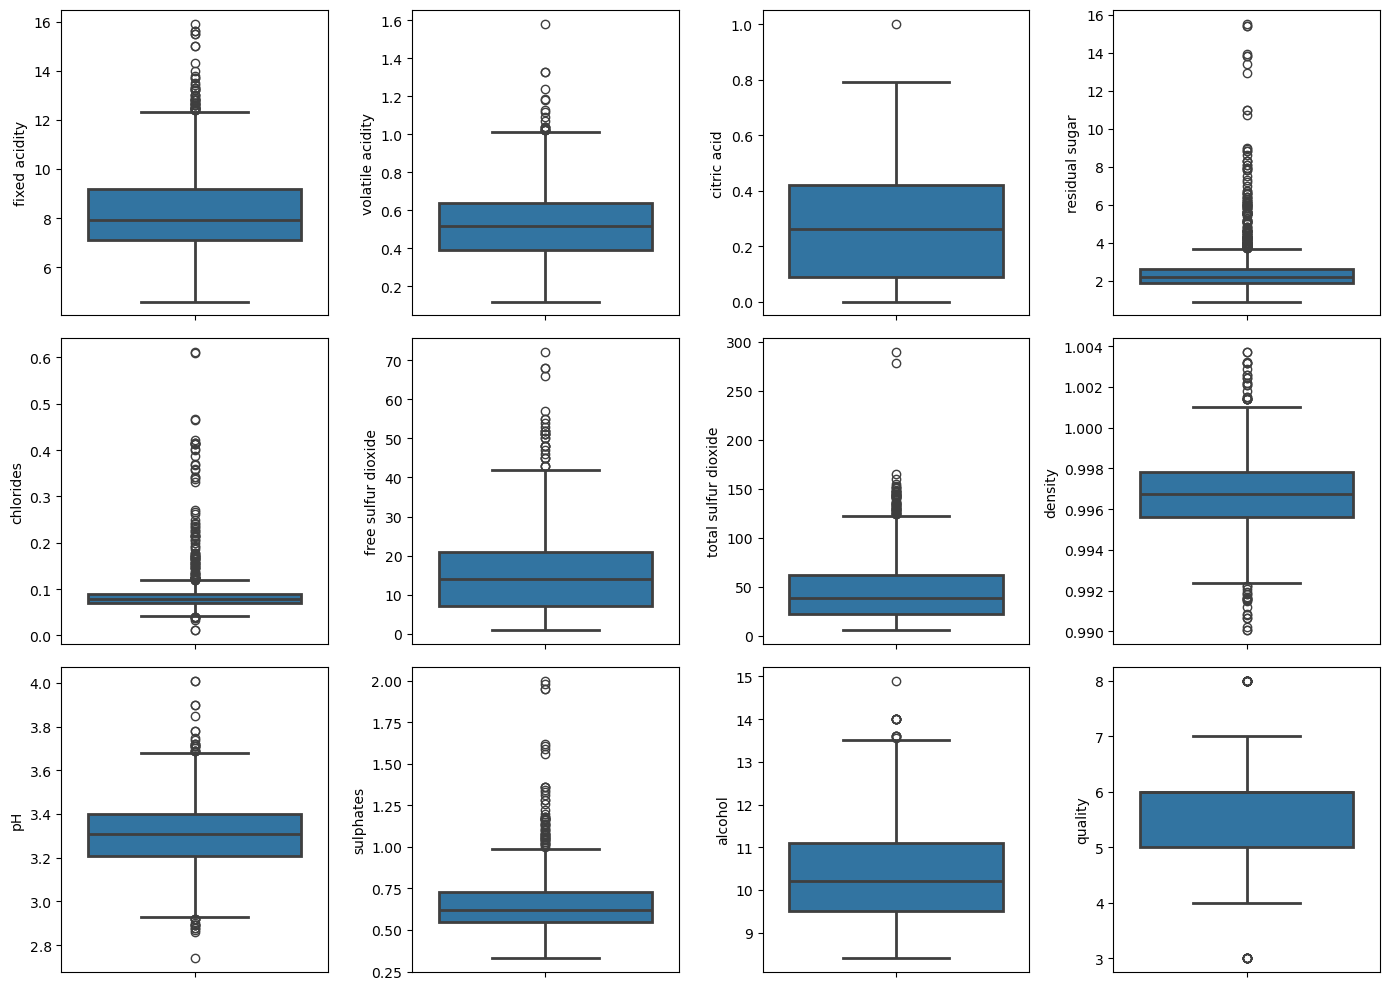

In [9]:
# Box plot to display the outliers
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(wine_data.columns):
  sns.boxplot(y=wine_data[col], ax=axes[i], linewidth=2)
plt.tight_layout()
plt.show()

In [10]:
# Detect outliers
for col in wine_data.columns:
  Q1 = wine_data[col].quantile(0.25)
  Q3 = wine_data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 3 * IQR
  upper_bound = Q3 + 3 * IQR

  # Get and display the count of outliers in each column
  outliers = wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]
  print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in fixed acidity: 5
Number of outliers in volatile acidity: 1
Number of outliers in citric acid: 0
Number of outliers in residual sugar: 88
Number of outliers in chlorides: 67
Number of outliers in free sulfur dioxide: 4
Number of outliers in total sulfur dioxide: 2
Number of outliers in density: 0
Number of outliers in pH: 2
Number of outliers in sulphates: 16
Number of outliers in alcohol: 0
Number of outliers in quality: 0


After running the above code, the output is generated and it shows that residual sugar, chlorides, and sulphates have the most outliers. Other columns like citric acid, density, alcohol, and quality have no outliers and it indicates their data is within a reasonable range(Battas et al., 2023, p. xx).

This function helps to count and shows the valuesin terms of percentage.

In [11]:
# Function to count and display values and % of values
def count_values_table(data):
  count_val = data.value_counts()
  count_val_percent = 100 * data.value_counts() / len(data)
  count_val_table = pd.concat([count_val, count_val_percent.round(1)], axis=1)
  count_val_table_ren_columns = count_val_table.rename(
      columns = {0 : 'Count Values', 1 : '% of Total Values'})
  return count_val_table_ren_columns

The function hist_chart helps to create a histogram using the fivethirtyeight style. It tells the missing values before plotting and provides labeled axes with a title

In [12]:
# Function to plot Histogram
def hist_chart(data, col):
  plt.style.use('fivethirtyeight')
  plt.hist(data[col].dropna(), edgecolor = 'k');
  plt.xlabel(col); plt.ylabel('Number of Entries');
  plt.title('Distribution of '+col);

The histogram plotting were done for the quality and count of the wine. The dataset distribution takes places and thus the end user can be able to visualize clearly.

         count  count
quality              
5          681   42.6
6          638   39.9
7          199   12.4
4           53    3.3
8           18    1.1
3           10    0.6 



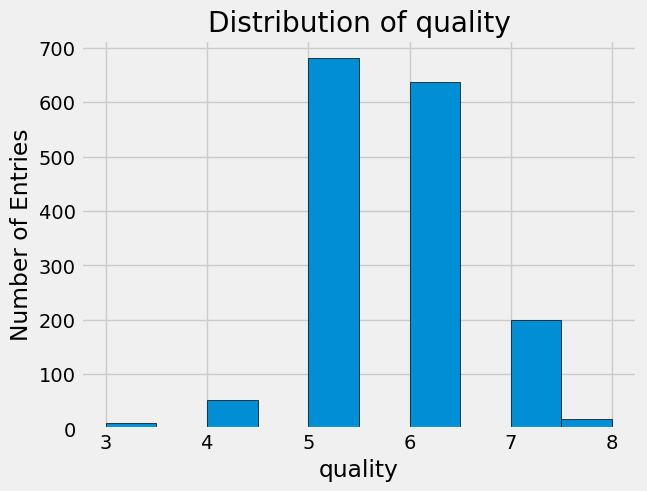

In [13]:
# Plot histogram of Quality to visualize the distribution
hist_chart(wine_data, 'quality')

# Display the count of each quality
print(count_values_table(wine_data.quality), "\n")

The above histogram clearly shows the quality and entries dataset(Alolyan & Simos, 2018, p. xx).

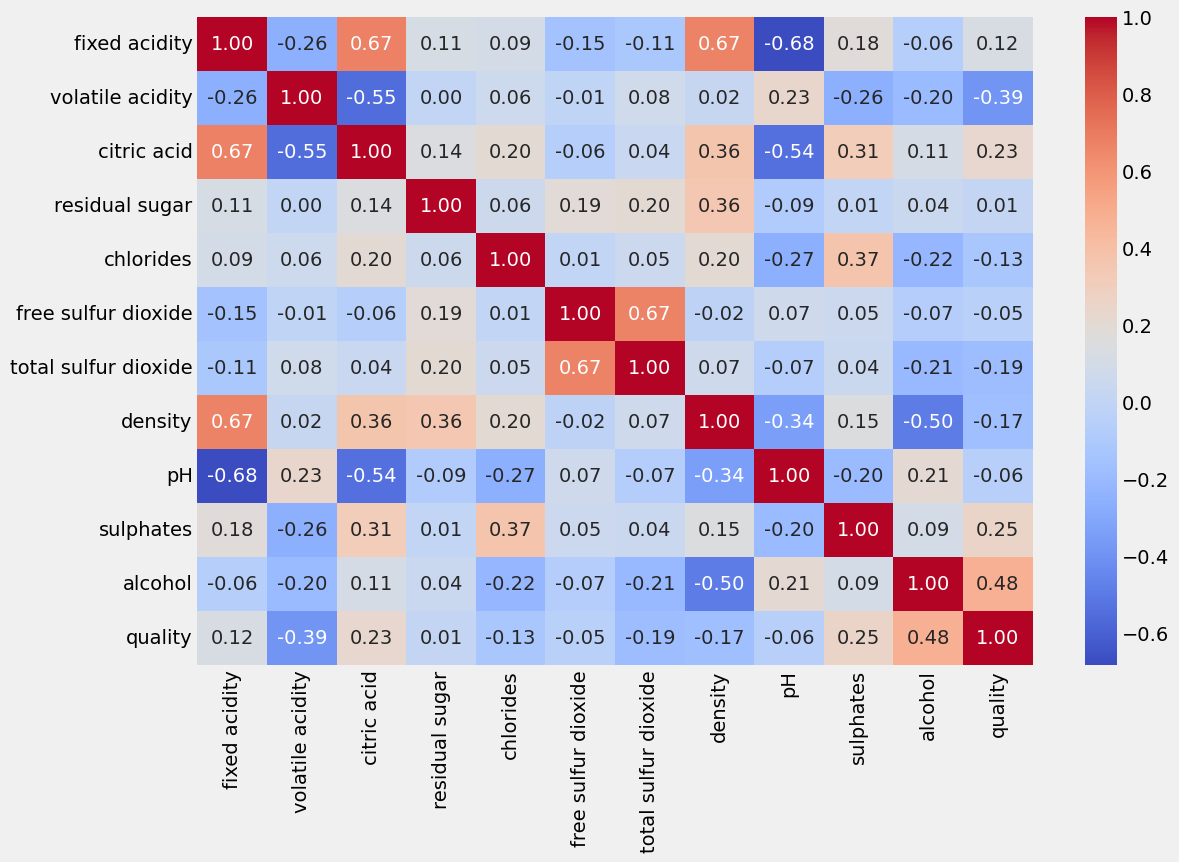

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

The given code helps to gnereate a correlation heatmap for the wine_data dataset. It does by setting the figure size to 12 by 8 inches to ensure readability. The sns.heatmap() function from Seaborn will be taken into account for plotting the heatmap. The annot=True ensures that the actual correlation values will be displayed within each cell, while the cmap='coolwarm' setting shows a diverse color palette to highlight positive and negative correlations. Finally, plt.show() helps to display the heatmap.

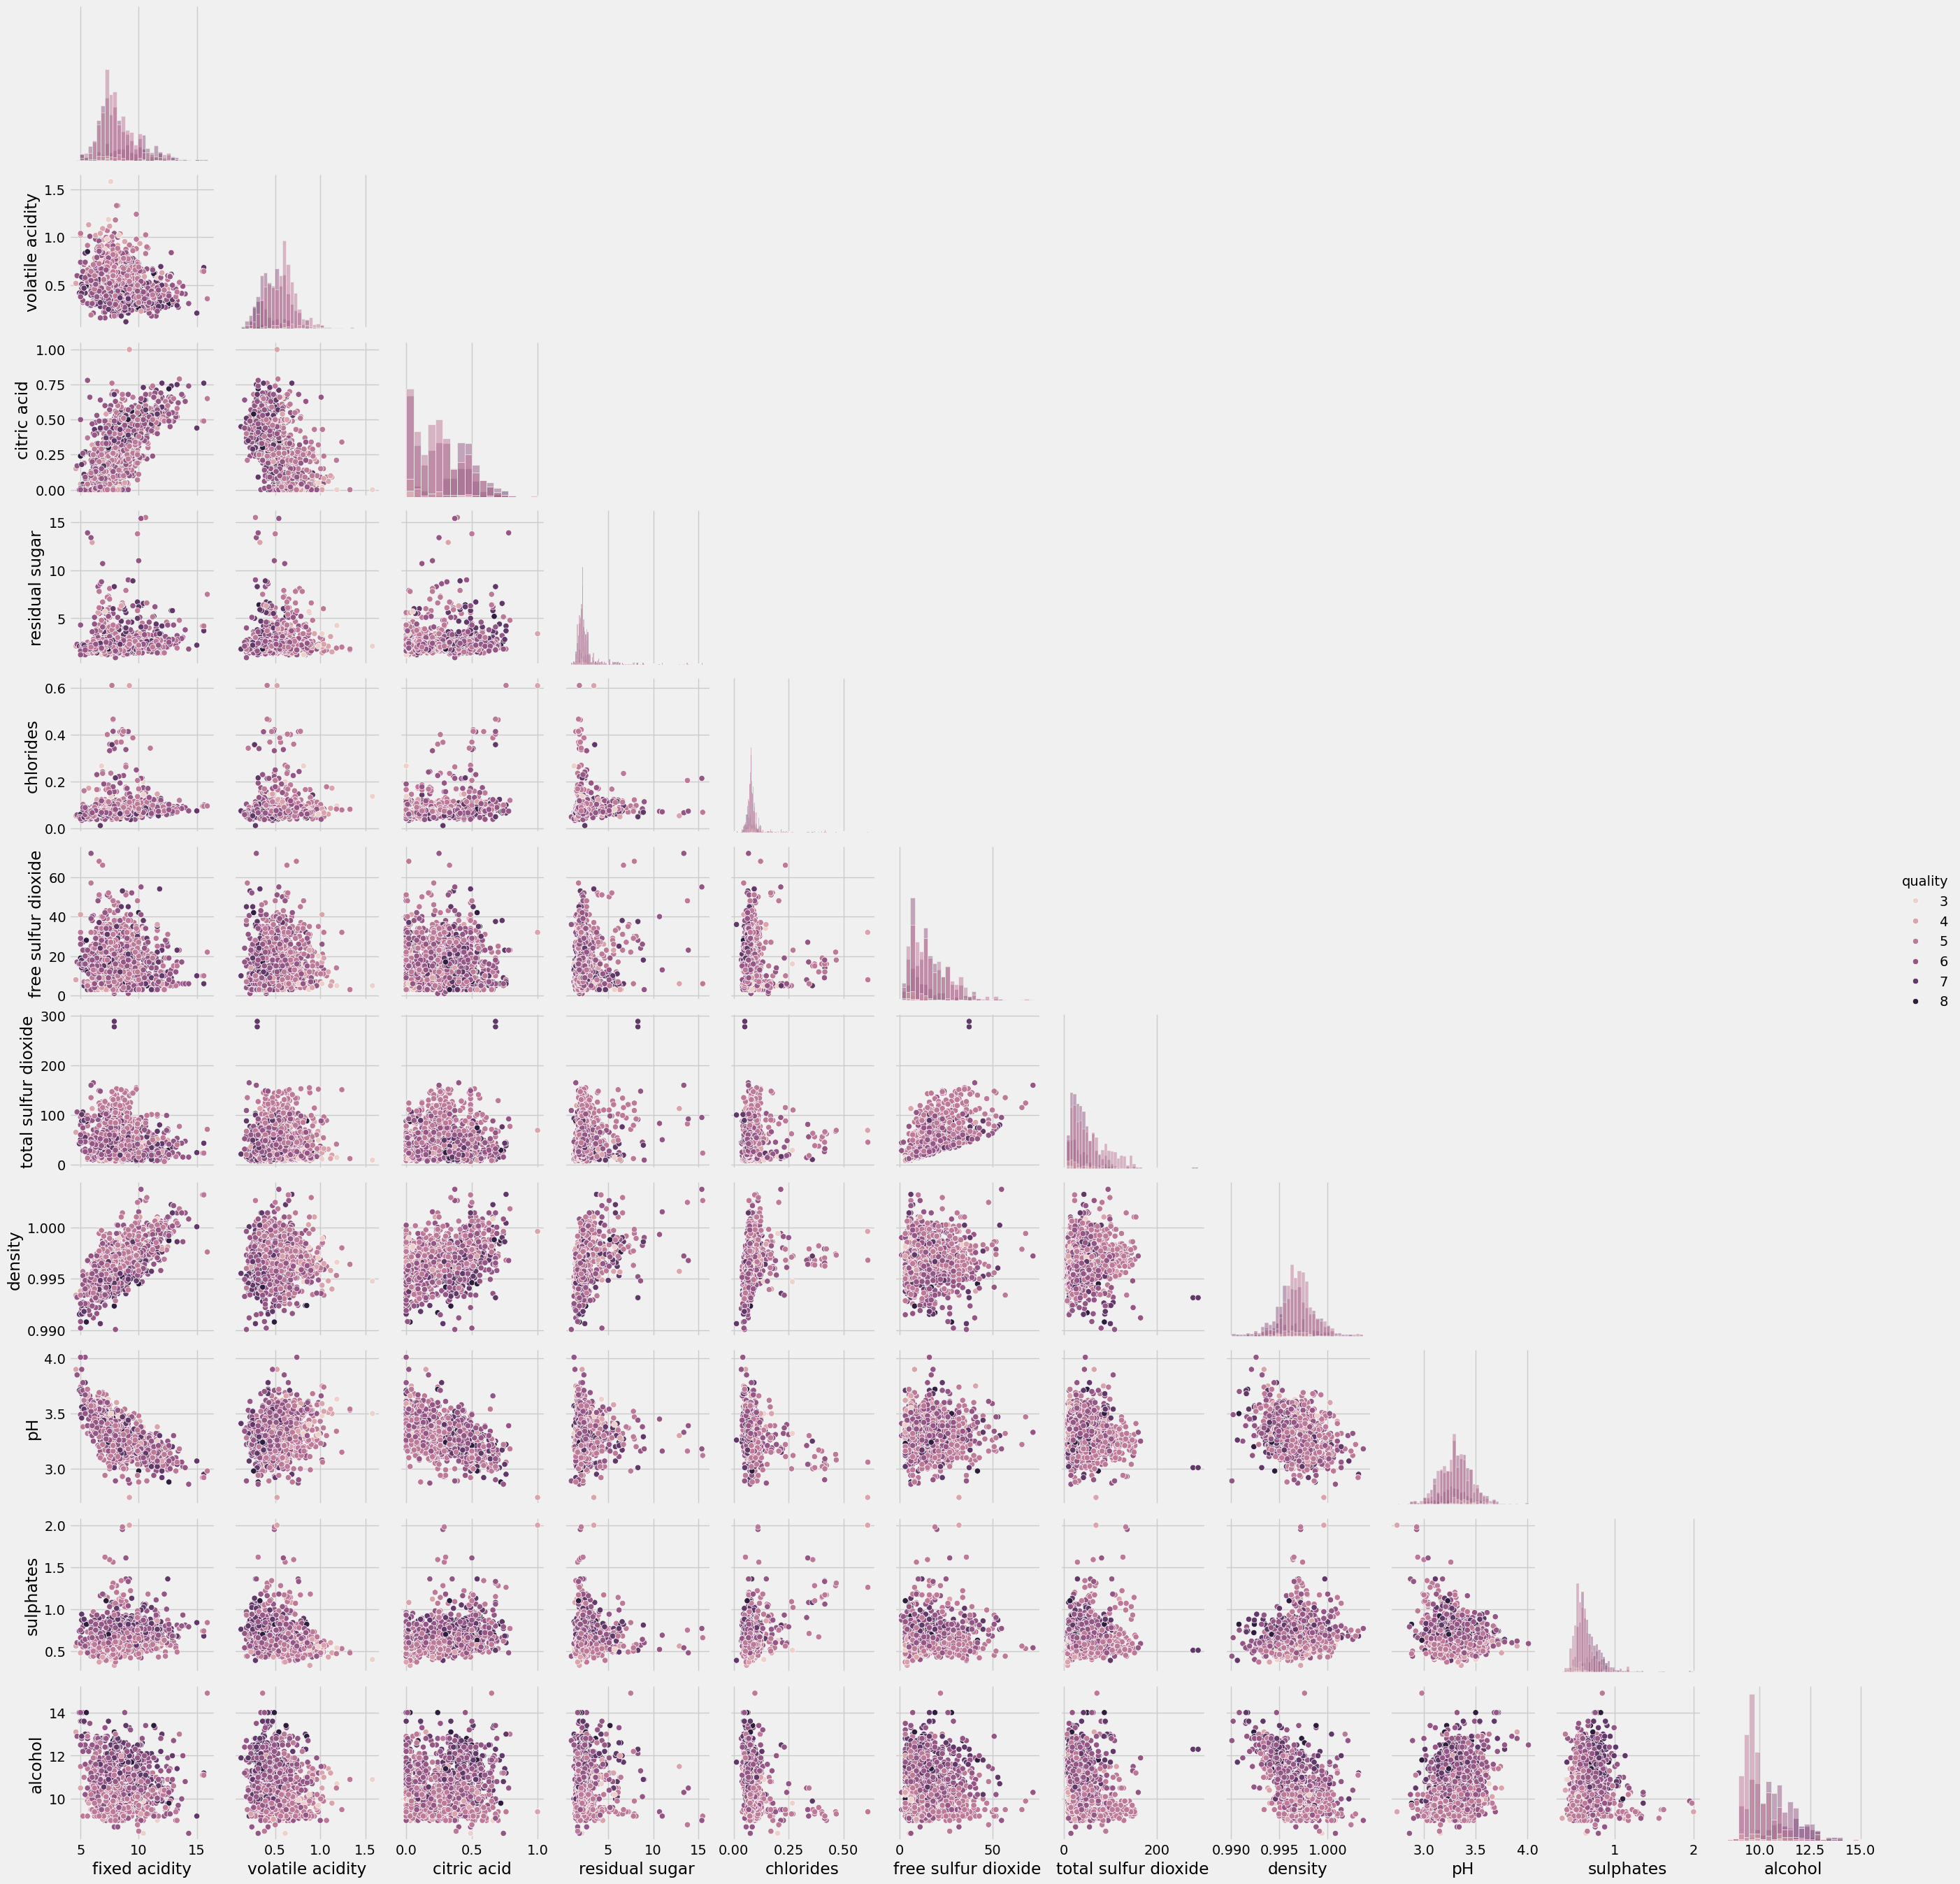

In [15]:
# Pair plot
sns.pairplot(wine_data, hue='quality', diag_kind="hist", corner=True)
plt.show()

The pair plotting were done for the chosen dataset and it includes multiple attributes. The data shown will be used and processed.

In [16]:
correlations = wine_data.corr()['quality'].abs().sort_values(ascending=False)

# Select features with correlation above 0.1
sel_features = correlations[correlations > 0.1].index.tolist()
sel_features.remove('quality')
print("Selected Features:\n")
for feature in sel_features:
  print(feature)

selected_data = wine_data[sel_features + ['quality']]

Selected Features:

alcohol
volatile acidity
sulphates
citric acid
total sulfur dioxide
density
chlorides
fixed acidity


The correlation were done to sort out the values based upon the features. The datset processing done and shows the above output values.

After the removal, it checks if any duplicates remain using duplicated().sum(), which counts them and the result is stored in duplicate_counts.
The print statement displays the number of duplicate rows left (should be 0 if removed successfully).This ensures that the dataset is clean and free from redundancy for accurate analysis.

The data removal can be done with the help of command below and it has been found that there is no duplicate data in it.

In [17]:
# Remove duplicates
selected_data = selected_data.drop_duplicates()

# Check for duplicated rows after removing
duplicate_counts = selected_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_counts}")

Number of duplicate rows: 0


This loop helps in removing the outliers from each column in the selected data with the help of Interquartile Range (IQR) method. The outliers are defined as values outside the range and the dataset is filtered to keep only the values that are within this range for each column. The usage of 3IQR instead of 1.5IQR helps in getting the filtering process less aggressive and keep more data.


In [18]:
# Remove  outliers
for col in selected_data.columns:
  Q1 = selected_data[col].quantile(0.25)
  Q3 = selected_data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 3 * IQR
  upper_bound = Q3 + 3 * IQR
  selected_data = selected_data[(selected_data[col] >= lower_bound) & (selected_data[col] <= upper_bound)]

This code helps to create the box plots to visualize the distribution of each column in the chosen dataset after outlier removal.You can set up a 3x3 grid of subplots using plt.subplots(), and you can flatten the axes for easy indexing.
Now, each column gets plotted using seaborn’s boxplot() to visualize the medians, quartiles, and outliers. The linewidth helps to make the plot borders clearer and tight_layout() helps to eliminate the overlapping plots. Finally, plt.show() helps tp show all the box plots in a single figure.

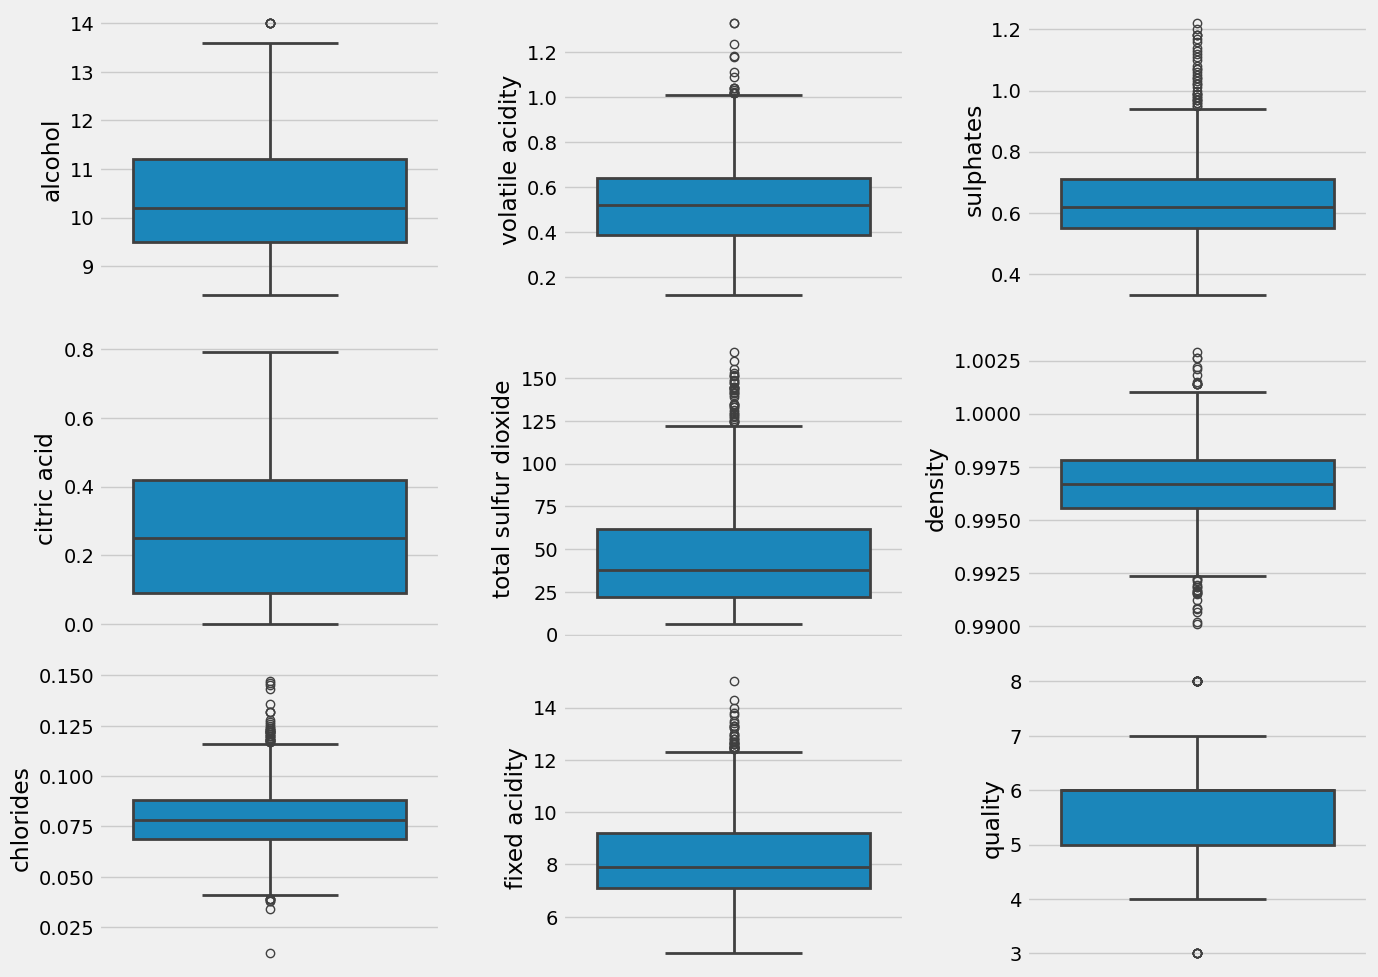

In [19]:
# Box plot to visalize data after removing outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(selected_data.columns):
  sns.boxplot(y=selected_data[col], ax=axes[i], linewidth=2)
plt.tight_layout()
plt.show()

This line helps in relabelling the quality column in selected_data to do the binary classification.Wine samples ranges from quality 3 to 5 are labeled as '1' will be considered as low quality.The samples with quality greater than 5 will be labeled as '0' and considered as an higher quality.Finally, unique() helps in checking  distinct labels to confirm the transformation was successful.

In [20]:
# quality 3-5 label as '1', quality > 5 label as '0'
selected_data["quality"] = np.where(selected_data["quality"] < 6, 1, 0)

# Display the unique values to ensure the conversion
selected_data["quality"].unique()

array([1, 0])

This code helps in splitting the dataset into features (X) and target (y) for model training.The X axis contains all columns except the input variables such as quality. The y contains only the quality column, which is the target variable for prediction.This structure required by most machine learning models in scikit-learn. It prepares the data for tasks like classification or regression(Alfiandi et al., 2025, p. xx).

In [21]:
# Define features and target
X = selected_data.drop('quality', axis=1)
y = selected_data['quality']

This code helps in splitting the dataset into 80% training and 20% testing sets with the help of command train_test_split.The test_size chosen as 0.2 parameter and it considers the 20% of the data for testing model performance. The random_state=42 helps to split the dataset for consistent results.
X_train and X_test help in holding the feature sets, while y_train and y_test hold the corresponding target labels. The print() statements reveals size of each set after the split.

In [22]:
# Split the data into training(80%) and testing(20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

# Display the shape of the train and test sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1025, 8)
Shape of X_test: (257, 8)
Shape of y_train: (1025,)
Shape of y_test: (257,)


In [23]:
# Import decision tree claasifier module
from sklearn.tree import DecisionTreeClassifier

This line used to import the DecisionTreeClassifier from scikit-learn's tree module.Decision Tree algorithm works by splitting the dataset into branches based on feature values and decision rules.The scikit-learn provides a simple API to train, test, and evaluate the decision trees.This import is the first step during the tree-based classification model building process.

In [24]:
# build a DT model with default parameters
dt_model = DecisionTreeClassifier(random_state=12)

# Train model using train set
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=12)

The  above creates a Decision Tree Classifier named dt_model with the help of default parameters. The random_state set to 12 and it ensures consistent tree structure on each run. The .fit() method helps to trains the model with the help of the training feature set (X_train) and target labels (y_train).
This model helps to learn the decision rules by splitting data based upon the feature values to classify wine quality. This trained model now do the  predictions with the help of unseen test data.

In [25]:
# Make predictions on test set
y_pred_dt = dt_model.predict(X_test)

# Calculate and display the model accuracy
acc = accuracy_score(y_test, y_pred_dt)
print(f"DT Model Accuracy: {acc:.4f}")

DT Model Accuracy: 0.6459


The trained Decision Tree model can be used to predict labels for the test set.
The predictions will be stored in y_pred_dt and they will be compared with actual values in y_test. The accuracy_score() helps in calculating the percentage of the correct predictions made by the model. The result will be stored in acc and printed with four decimal places. It will offer a quick assessment of the overall performance of the model based on unseen data.


In [26]:
# classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.65      0.70      0.67       135
           1       0.64      0.59      0.61       122

    accuracy                           0.65       257
   macro avg       0.64      0.64      0.64       257
weighted avg       0.65      0.65      0.64       257



The classification_report function provides a detailed summary of a classification model's performance specifically for each class in the dataset.


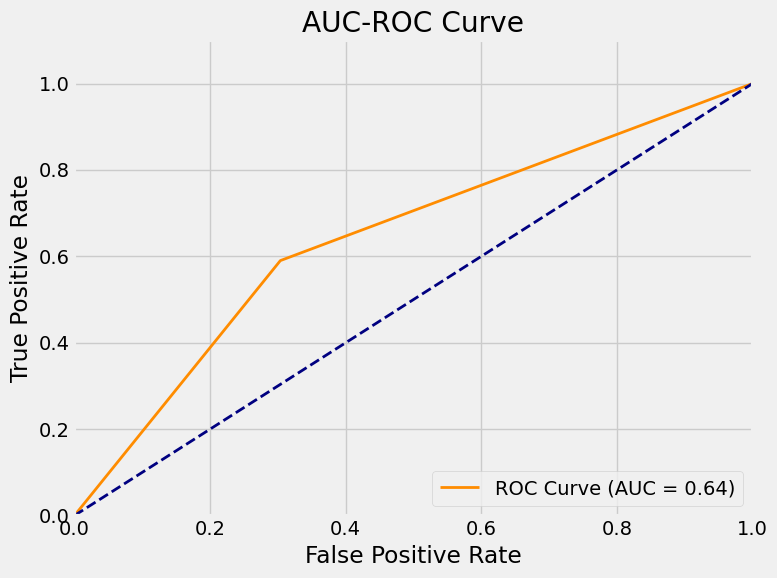

In [27]:
# Calculate ROC curve and AUC
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot AUC-ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The above code is aimed at calculating the ROC curve and the Area Under the Curve for a model's predictions, specifically for a decision tree classifier. It helps in plotting the AUC-ROC curve with relevant labels and annotations.

In [28]:
# Hyperparameter Tuning

# define a parameter grid for tuning
param_grid = {
    'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_features': [None, 'sqrt', 'log2']
    }

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=12), 
                           param_grid=param_grid, cv=5, scoring='roc_auc', 
                           n_jobs=-1, verbose=1)

# Fit the grid search to the training data.
grid_search.fit(X_train, y_train)

# Display the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation AUC-ROC score: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 16200 candidates, totalling 81000 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 9, 'splitter': 'random'}
Best cross-validation AUC-ROC score: 0.8027


This code helps in hyperparameter tuning for a DecisionTreeClassifier with the help of Grid Search with 5-fold cross-validation. The parameter grid were defined with values for key hyperparameters. The grid search evaluates the model using the AUC-ROC score as the performance metric. The best hyperparameters and its corresponding AUC-ROC score will be printed after fitting the grid search to the training data. For better performance, this approach will optimize the decision tree model.

In [29]:
# Get the best DT model
best_dt_model = grid_search.best_estimator_

# make prediction on test data
y_pred_tuned_dt = best_dt_model.predict(X_test)

# Calculate and display the tuned DT model accuracy
tuned_dt_acc = accuracy_score(y_test, y_pred_tuned_dt)
print(f"Tuned DT Model Accuracy: {tuned_dt_acc:.4f}\n")

Tuned DT Model Accuracy: 0.7198



This code will be the best decision tree model from the grid search command after performing hyperparameter tuning. Then, it adopts the tuned model to do the predictions on the test data. The accuracy of the tuned decision tree model will be calculated using accuracy_score and displayed. The total accuracy of the DT model calculated and it is 0.7198.



In [30]:
# classification report
print(classification_report(y_test, y_pred_tuned_dt))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73       135
           1       0.70      0.70      0.70       122

    accuracy                           0.72       257
   macro avg       0.72      0.72      0.72       257
weighted avg       0.72      0.72      0.72       257



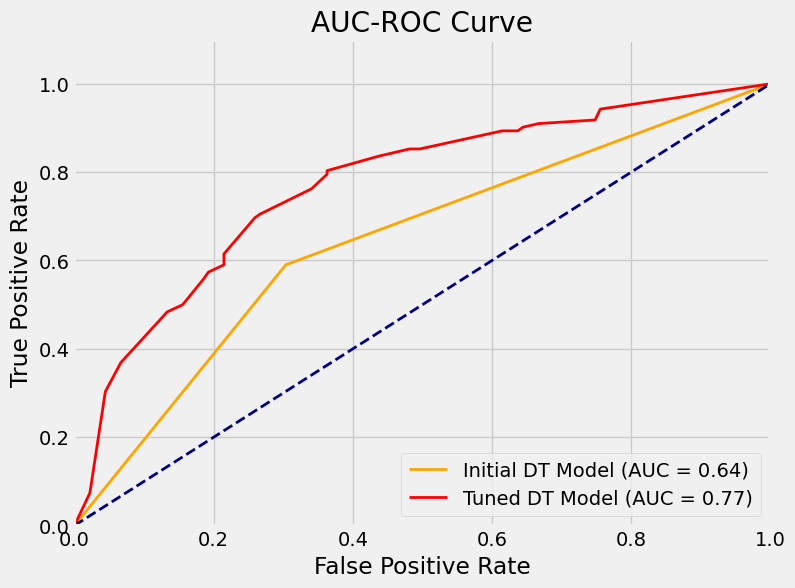

In [31]:
# Calculate ROC curve and AUC for the tuned model
y_pred_proba_tuned = best_dt_model.predict_proba(X_test)[:, 1]
fpr_dt_tuned, tpr_dt_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)
roc_auc_tuned = auc(fpr_dt_tuned, tpr_dt_tuned)

# Plot AUC-ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, 
         label=f'Initial DT Model (AUC = {roc_auc:.2f})')
plt.plot(fpr_dt_tuned, tpr_dt_tuned, color='red', lw=2, 
         label=f'Tuned DT Model (AUC = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve')
plt.legend(loc="lower right")
plt.show()


The model assessment done to predict the success of the criteria and test design. The application modelling and discovery techniques will be discussed in terms of business point of view. The parameter seetings will be revised and tuned according to the end user.


It is done to test the accuracy and genrality of the model chosen. This will determine how the model meets the objective of business and detects if there is any defect in the chosen model.


This stage mainly helps in determining the strategy to monitor the model and how it impacts the business operations. The accessment of the certain things done and code will be inserted to do the assigned task.


# Conclusion

The above commands helps in building the predictive model with the help of given dataset. The analysis of the dataset helps in training and testing the dataset efficiently.

# References

Alfiandi, A., S.D, T., & Fitriana, R. (2025). Quality improvement of DB-CDP with integration of CRISP-DM and Six Sigma method. Operations Excellence: Journal of Applied Industrial Engineering, 16(3), 309. https://doi.org/10.22441/oe.2024.v16.i3.126

Alolyan, I., & Simos, T. E. (2018). A family of six–stages embedded explicit six–step schemes with optimized properties. AIP Conference Proceedings, 2040, 150016. https://doi.org/10.1063/1.5079219

Battas, I., Behja, H., & Deshays, L. (2023). DMAICS 2 CRISP DM approach for improving and optimising the performance of an industrial mining production process. International Journal of Six Sigma and Competitive Advantage, 1(1). https://doi.org/10.1504/ijssca.2023.10057132

Dursun, M., & Sabyrzhan, M. (2024). CRISP - DM process in smart building management. 2024 11th International Conference on Electrical and Electronics Engineering (ICEEE), 310-315. https://doi.org/10.1109/iceee62185.2024.10779257

Peker, S., & Kart, Ö. (2023). Transactional data-based customer segmentation applying CRISP-DM methodology: A systematic review. Journal of Data, Information and Management, 5(1-2), 1-21. https://doi.org/10.1007/s42488-023-00085-x

Rachman, M. A., & Sukmono, T. (2023). Implementation of neighbor’s k-nearest algorithm for mixer truck damage prediction with CRISP-DM approach. https://doi.org/10.21070/ups.1473

Schröer, C., Kruse, F., & Gómez, J. M. (2021). A systematic literature review on applying CRISP-DM process model. Procedia Computer Science, 181, 526-534. https://doi.org/10.1016/j.procs.2021.01.199

Tunca, S. (2024). Forecasting the enrolment of bank term deposits: A case study approach with cross-industry standard process for data mining (CRISP-DM) methodology. https://doi.org/10.21203/rs.3.rs-3921578/v1
